# Activity: Clustering with the Iris Dataset

#### Overview
In this session, we focus on the application of clustering techniques to the Iris dataset, a classic in the field of machine learning. Our objective is to explore how clustering algorithms can identify and group similar species based on their morphological characteristics.

#### What We Will Do:
- Dataset Examination: Investigate the Iris dataset to comprehend the features that distinguish different iris species.
- K-means Clustering: Apply K-means clustering, use the Elbow Method and Silhouette Analysis to find the optimal number of clusters, and visualize the grouping.
- Hierarchical Clustering: Experiment with hierarchical clustering using various linkage criteria, analyze the data structure with dendrograms, and determine the appropriate number of clusters.
- Evaluation and Comparison: Calculate Silhouette Coefficients for both clustering approaches and compare the results to evaluate the quality of the segmentation.
- Interpretation and Insights: Discuss the clustering patterns discovered and consider their biological significance, potentially providing insights into the taxonomy of iris species.

#### Outcome
By the conclusion of this session, we will have a clear understanding of how clustering algorithms such as K-means and hierarchical clustering can be leveraged to uncover natural groupings in data. We will learn to evaluate and interpret clustering results, fostering a deeper appreciation of how machine learning can be applied to biological classification and the broader field of data-driven discovery.

### Iris Flowers 

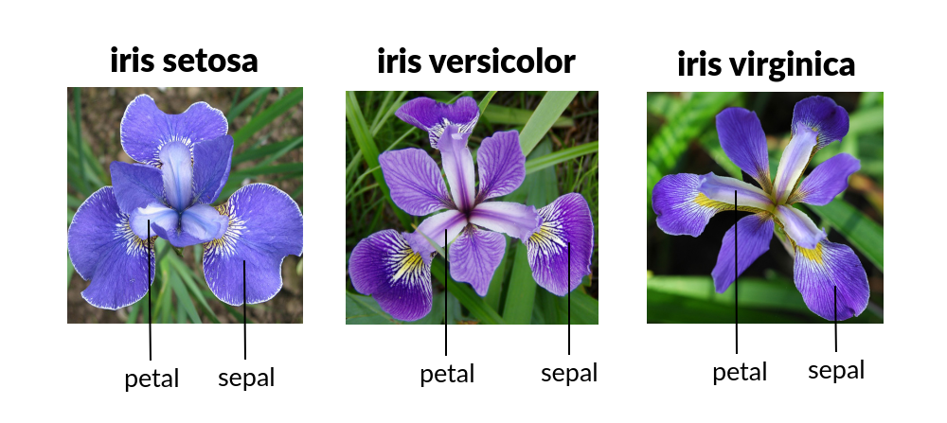

## 1.Import necessary libraries

In [1]:
import os
# Set OMP_NUM_THREADS environment variable to 1
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# For KMeans Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# For Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [21]:
# Note: If you have recently upgraded Scikit-Learn to version '1.3.2' and encounter an error like:
# AttributeError: 'NoneType' object has no attribute 'split'
# This issue may be related to the 'threadpoolctl' package. To resolve it, ensure 'threadpoolctl' is up-to-date. 
# You can update 'threadpoolctl' by running the following command in your environment:
# pip install --upgrade threadpoolctl

## 2. Load the Iris dataset

In [2]:
iris_data = pd.read_csv('../data/iris.csv', index_col=0)

# Display the first few rows
iris_data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


- **Loading the Dataset**: We start by loading the Iris dataset directly from scikit-learn and converting it into a Pandas DataFrame. This makes it easier to work with the data using Pandas functions.

## 3. Exploratory Data Analysis (EDA)

- **EDA**: The descriptive statistics provide a quick overview of the data, helping us understand the scale and distribution of each feature. The pair plot is a powerful tool for visual EDA, as it shows both the distribution of individual features and the relationships between them. From the pair plot, we can start to see how the data might form clusters.

- Descriptive statistics

In [5]:
# Descriptive statistics
iris_data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


#### Pair plot

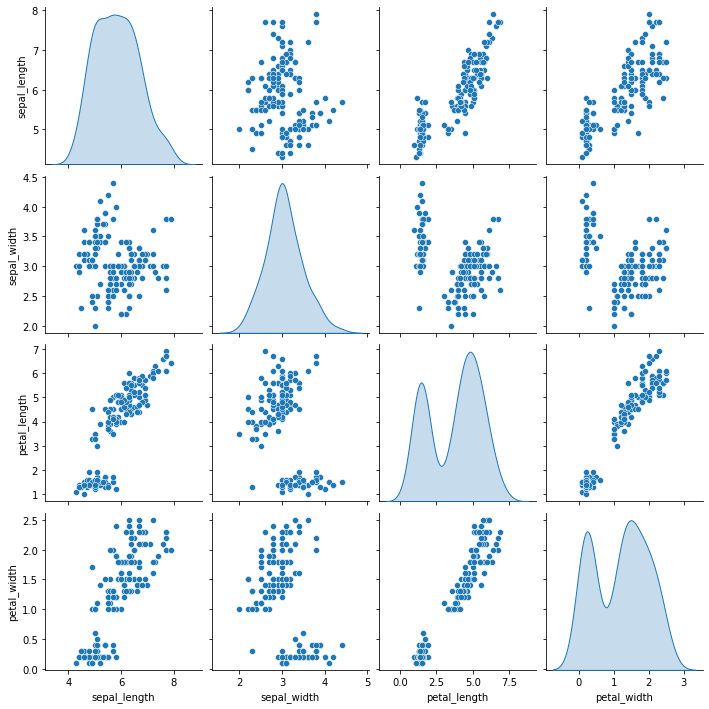

In [18]:
# Pair plot
sns.pairplot(iris_data, diag_kind='kde')
plt.show()

#### Pair Plot with Target Variable

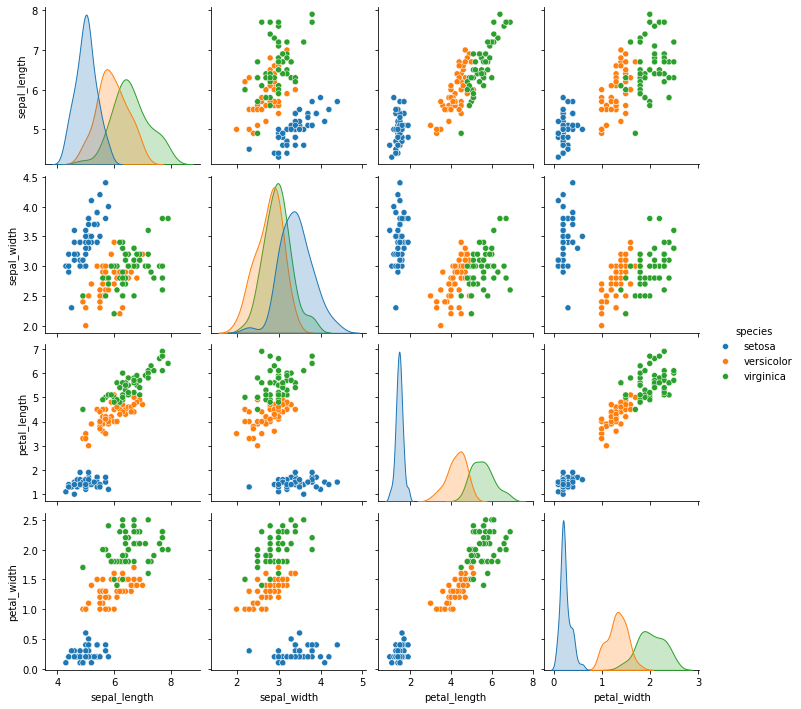

In [20]:
# Pair plot with species as hue
sns.pairplot(iris_data, hue='species', diag_kind='kde')
plt.show()

Upon observing the pair plot, we can make several insightful observations:

- **Species Distinction**: The species, now labeled with names like 'Setosa', 'Versicolor', and 'Virginica', show distinct patterns. Particularly, 'Setosa' appears to be clearly separable from 'Versicolor' and 'Virginica' in almost all feature combinations.

- **Feature Correlations and Differences**: The plots reveal varying degrees of overlap between 'Versicolor' and 'Virginica', especially in sepal measurements. However, the petal measurements (length and width) exhibit a clearer distinction among all three species.

- **Importance of Petal Features**: The petal length and width are notably more discriminative in differentiating species. 'Setosa' exhibits smaller petal lengths and widths, while 'Versicolor' and 'Virginica' have larger petals but with some overlap.

- **Clustering Insights**: The visual separation suggests that a clustering algorithm might effectively distinguish 'Setosa' from the others. However, differentiating 'Versicolor' from 'Virginica' could be more challenging, pointing to the potential need for a sophisticated approach or feature selection.

## 4. Data Preprocessing

- Selecting only the features

In [5]:
# Selecting only the features
iris_features = iris_data.drop('species', axis=1)
iris_features.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


- Scaling the features

In [6]:
# Scaling the features
scaler = StandardScaler()
scaled_iris_features = scaler.fit_transform(iris_features)

# Convert scaled data back to DataFrame for easier viewing
scaled_iris_features = pd.DataFrame(scaled_iris_features, columns=iris_features.columns)
scaled_iris_features.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


- **Preprocessing**: We use `StandardScaler` for feature scaling. This step is vital for clustering algorithms that rely on distance calculations, like K-means, because it ensures all features contribute equally to the result. The scaled data is then ready for clustering algorithms.

## 5. Kmeans Clustering

### 1. Determining the Optimal Number of Clusters

#### Objective
To determine the optimal number of clusters for the K-means algorithm applied to the Iris dataset using the Elbow Method and Silhouette Analysis.

#### 1. Elbow Method

- **Elbow Method**: The Elbow Method is visualized by plotting the inertia (sum of squared distances) for different numbers of clusters. The 'elbow point' is where the rate of decrease in inertia becomes more gradual, indicating a suitable number of clusters.

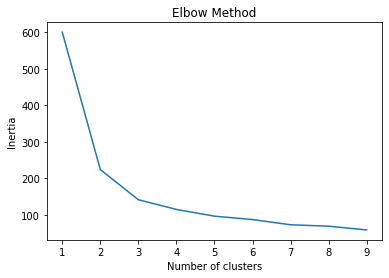

In [19]:
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, n_init = 'auto', random_state=0).fit(scaled_iris_features)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.plot(range(1, 10), inertia)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

#### 2. Silhouette Analysis

- **Silhouette Analysis**: Silhouette scores are calculated for each k (number of clusters) and plotted. A higher silhouette score indicates better cluster separation. The optimal number of clusters is typically where the silhouette score peaks.

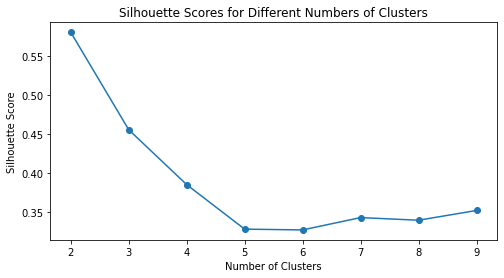

In [21]:
# Performing Silhouette Analysis
silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state = 0).fit(scaled_iris_features)
    score = silhouette_score(scaled_iris_features, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting Silhouette Scores
plt.figure(figsize=(8, 4))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

##### Interpretation of Elbow Method and Silhouette Analysis Results

The Elbow Method plot displays a consistent decrease in inertia as the number of clusters increases. Although there is no pronounced 'elbow,' a slight bend can be observed at 2 clusters. This indicates that beyond 2 clusters, the reduction in within-cluster variance (inertia) is not as significant.

The Silhouette Analysis plot provides a more nuanced perspective. It shows that the silhouette score is highest when the number of clusters is 2, suggesting that two clusters have the best average silhouette score. This aligns with the observation from the EDA, where the distinction between 'Virginica' and 'Versicolor' is not very clear, and hence, a 2-cluster solution seems appropriate based on these results.

However, for educational purposes and to align with the known classification of three species in the dataset, we proceed with 3 clusters for K-means to facilitate a comparison with the actual species labels.


### 2. Implementing K-means Clustering and Comparative Analysis with original data

#### KMeans with 3 clusters

In [7]:
# Fit K-means with the optimal number of clusters (assume 3 from the plot)
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, n_init = 'auto', random_state=0).fit(scaled_iris_features)
iris_data['cluster_KMeans'] = kmeans.labels_
# Disply the first rows of iris_data includign the cluster created
iris_data.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster_KMeans
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


**K-means Clustering**: The model is fitted with the optimal number of clusters (3 in this case). A new column 'cluster' is added to the dataset, indicating the cluster assignment for each data point.

#### Visualize the clusters

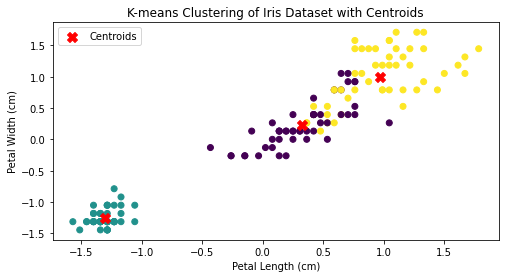

In [8]:
# Visualization of Clusters with Centroids
plt.figure(figsize=(8, 4))
plt.scatter(scaled_iris_features['petal_length'], scaled_iris_features['petal_width'], c=iris_data['cluster_KMeans'], cmap='viridis')

# Plotting the centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 2], centroids[:, 3], c='red', s=100, marker='X', label='Centroids') # column 2 and 3 are petal length and width

plt.title('K-means Clustering of Iris Dataset with Centroids')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.show()

#### Interpretation of K-means Clustering Results with Centroids

The K-means clustering plot with centroids shows that the algorithm has identified three distinct groups, with centroids marked by red 'X's. These centroids represent the average position of data points within each cluster. The separation between the bottom cluster (presumably 'Setosa') and the other two is clear, which is consistent with the known high distinguishability of 'Setosa' from 'Versicolor' and 'Virginica.' The other two clusters, while distinct, are closer together, indicating the more subtle differences between 'Versicolor' and 'Virginica' species.

### 3.Comparative Analysis with original Species

#### Comparative Analysis - Cross Table

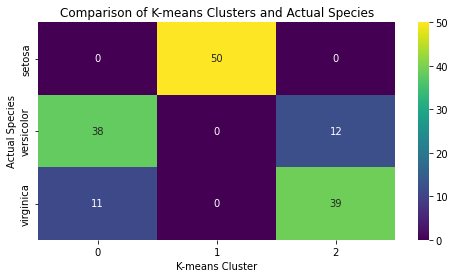

In [9]:
# Comparative Analysis
# Original species labels are in the DataFrame named iris_data
contingency_table = pd.crosstab(iris_data['species'], iris_data['cluster_KMeans'])

# Heatmap for Comparative Analysis
plt.figure(figsize=(8, 4))
sns.heatmap(contingency_table, annot=True, cmap='viridis', fmt='d')
plt.title('Comparison of K-means Clusters and Actual Species')
plt.xlabel('K-means Cluster')
plt.ylabel('Actual Species')
plt.show()

 **Comparative Analysis**: A contingency table compares the clusters with the actual species. A heatmap visualizes this comparison, providing a clear and intuitive way to see how well the K-means clusters align with the actual species. Differences between the clusters and the actual species can highlight the algorithm's strengths and limitations. 


##### Interpretation of Comparison of K-means Clusters and Actual Species

In the comparison heatmap, we notice that the 'Setosa' species is perfectly clustered with no misclassification. However, there's some overlap between 'Versicolor' and 'Virginica,' as expected from the EDA and silhouette analysis. The K-means algorithm tends to group some 'Virginica' as 'Versicolor' and vice versa. This demonstrates the challenge K-means faces when clusters have some degree of overlap and aren't perfectly separable.

#### Comparative Analysis - Side-by-Side Scatter Plot

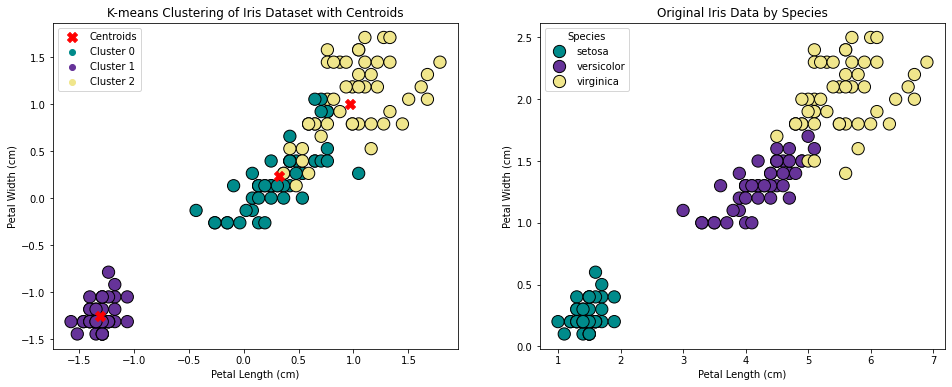

In [10]:
# get controids of kmeans model
centroids = kmeans.cluster_centers_

# Custom color mapping for clusters
cluster_colors = {0: 'darkcyan', 1: 'rebeccapurple', 2: 'khaki'}
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

# Visualization of Clusters with Centroids
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Cluster Visualization with Centroids
cluster_colors_list = [cluster_colors[label] for label in iris_data['cluster_KMeans']]
ax[0].scatter(scaled_iris_features['petal_length'], scaled_iris_features['petal_width'], c=cluster_colors_list, edgecolor='k', s=150)

# Plotting the centroids
ax[0].scatter(centroids[:, 2], centroids[:, 3], c='red', s=100, marker='X', label='Centroids') # Assuming columns 2 and 3 are petal length and width
ax[0].set_title('K-means Clustering of Iris Dataset with Centroids')
ax[0].set_xlabel('Petal Length (cm)')
ax[0].set_ylabel('Petal Width (cm)')

# Adding custom legend for clusters
for cluster_num, color in cluster_colors.items():
    ax[0].scatter([], [], color=color, label=cluster_labels[cluster_num])
ax[0].legend()

# Original Data Visualization
species_palette = {'setosa': 'darkcyan', 'versicolor': 'rebeccapurple', 'virginica': 'khaki'}
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=iris_data, ax=ax[1], palette=species_palette, edgecolor='k', s=150)
ax[1].set_title('Original Iris Data by Species')
ax[1].set_xlabel('Petal Length (cm)')
ax[1].set_ylabel('Petal Width (cm)')
ax[1].legend(title='Species')

plt.show()


- **Side-by-Side Visualization**: The `plt.subplots` function is used to create two subplots side by side. The left plot shows the K-means clustering result with centroids, while the right plot displays the original data colored by species.
- **Cluster Visualization with Centroids**: The first subplot visualizes the K-means clusters along with the centroids, providing insight into the clustering pattern and central points.
- **Original Data Visualization**: The second subplot uses Seaborn's `scatterplot` to plot the original Iris data, colored by the actual species. This allows for a direct visual comparison with the clustering results.
- **Comparative Analysis**: By placing these plots side by side, you can easily compare the K-means clustering arrangement with the true species distribution, offering insights into the clustering accuracy and areas where the algorithm may have misclassified data points.

##### Side-by-Side Visualization Interpretation

The side-by-side scatter plots offer a direct visual comparison between K-means clustering results and the actual species classification. The color scheme helps to visually equate the clusters with the species. Despite the different colors and cluster numbers, it's clear that K-means clustering has done a reasonable job of grouping the data points, especially for 'Setosa,' which is distinctly separated from the other two species in both plots.

#### Additional Interpretations and Considerations

- The results show the limitations of K-means when dealing with overlapping clusters, as it assumes clusters to be of similar size and shape, which is not always the case in real-world data.
- K-means is sensitive to the initial placement of centroids. Therefore, different runs might produce slightly different results, especially in datasets with less well-defined clusters.
- It can be valuable for students to experiment with a 2-cluster K-means clustering to observe the difference and better understand the importance of choosing the correct number of clusters.
- Students should be encouraged to not only rely on quantitative methods like the Elbow Method and Silhouette Analysis but also consider the context and prior knowledge about the dataset when determining the number of clusters.

## 7. Hierarchical Clustering

### 1. Analyzing Hierarchical Relationships with Dendrograms

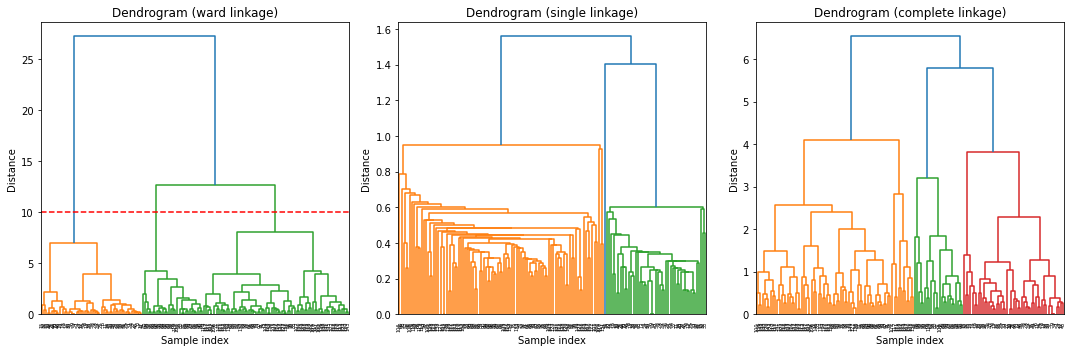

In [46]:
# Hierarchical clustering using different linkage methods
linkage_methods = ['ward', 'single', 'complete']

# Create a figure for subplots
plt.figure(figsize=(15, 5))

# Perform hierarchical clustering and plot dendrograms for each linkage method
for i, method in enumerate(linkage_methods):
    # Compute the linkage matrix
    Z = linkage(scaled_iris_features, method=method)
    
    # Create a subplot for the dendrogram
    plt.subplot(1, len(linkage_methods), i+1)
    
    # Plot the dendrogram
    dendrogram(Z)
    plt.title(f'Dendrogram ({method} linkage)')
    plt.xlabel('Sample index')
    plt.ylabel('Distance')
    
    # Annotate the height at which clusters will be distinguished for this method
    plt.axhline(y=10, color='r', linestyle='--')

plt.tight_layout()
plt.show()


#### Explanation
The code above generates and plots dendrograms for each specified linkage method. The dendrograms help visualize how each data point is merged into clusters hierarchically. The red dashed line at `y=10` is an arbitrary threshold to visually aid in determining a reasonable number of clusters. By examining where significant merges in the dendrogram occur, students can infer the natural grouping within the data:

- **Ward Linkage**: Tends to create more equally sized clusters and might suggest a different number of clusters based on variance minimization.
- **Single Linkage**: Often results in a chaining effect where clusters are merged sequentially, which can suggest a large number of small clusters or one large cluster.
- **Complete Linkage**: Looks for maximum distances and can suggest more compact clusters.

The 'ward' linkage typically suggests around 2 or 3 clusters for the Iris dataset, whereas 'single' and 'complete' might suggest different numbers based on how the dendrogram is interpreted.


#### Dendrogram Interpretation

- **Ward Linkage**: The dendrogram using Ward linkage shows a clear grouping at a larger distance, which indicates that the data points are well separated into distinct clusters. The cut-off line at a distance of 10 suggests that two main clusters might be an optimal choice, but considering our knowledge of the Iris dataset, which has three species, we would look for a cut-off that results in three clusters.

- **Single Linkage**: This dendrogram has a chain-like structure, which is typical for single linkage. It suggests that clusters are formed by gradually linking individual observations based on the shortest distance. This method is sensitive to noise and outliers, which can lead to less meaningful clusters. The red dashed line does not intersect any clusters, indicating that it is not a clear choice for cutting the dendrogram to form distinct clusters.

- **Complete Linkage**: The complete linkage dendrogram shows a more balanced structure compared to single linkage, with clusters forming at various levels of distance. The cut-off line at a distance of 10 intersects the dendrogram at several points, suggesting that three clusters could be formed, which aligns with the actual number of species.

### 2. Implementing Agglomerative Clustering 

In [11]:
# Apply Agglomerative Clustering with the chosen linkage method
chosen_linkage = 'ward'  # Based on Task 6 analysis
agg_cluster = AgglomerativeClustering(n_clusters=3, linkage=chosen_linkage)
clusters = agg_cluster.fit_predict(scaled_iris_features)

# Add the cluster labels to the dataset
iris_data['cluster_HAC'] = clusters

iris_data.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster_KMeans,cluster_HAC
0,5.1,3.5,1.4,0.2,setosa,1,1
1,4.9,3.0,1.4,0.2,setosa,1,1
2,4.7,3.2,1.3,0.2,setosa,1,1
3,4.6,3.1,1.5,0.2,setosa,1,1
4,5.0,3.6,1.4,0.2,setosa,1,1


#### Explanation 
The Agglomerative Clustering algorithm is applied to the scaled Iris dataset using the 'ward' linkage method. The predicted clusters are then compared to the actual species. The heatmap of the contingency table provides a visual representation of this comparison:

- The rows represent the actual species from the dataset.
- The columns represent the clusters predicted by the hierarchical clustering model.
- The numbers in the heatmap show how many instances of each actual species were assigned to each predicted cluster.

### 3. Comparative Analysis with original data

#### Comparative Analysis - Cross Table

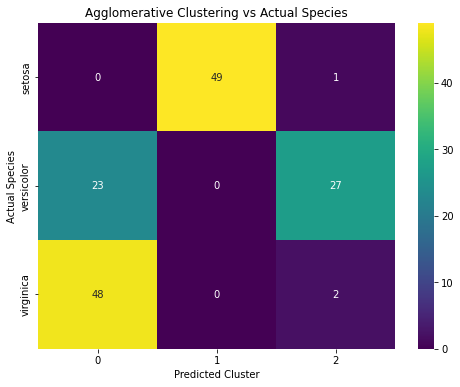

In [12]:
# Comparative Analysis: compare with original species labels
contingency_table = pd.crosstab(iris_data['species'], iris_data['cluster_HAC'])

# Visualize the contingency table with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, cmap='viridis', fmt='d')
plt.title('Agglomerative Clustering vs Actual Species')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Species')
plt.show()

#### Agglomerative Clustering vs. Actual Species

The heatmap represents a contingency table comparing the clusters predicted by HAC with the actual species. From the heatmap:

- **Setosa**: Almost perfectly classified into a single cluster with minimal misclassification.
- **Versicolor**: Shows some misclassification, with data points being classified into the clusters primarily holding 'Virginica'.
- **Virginica**: Similarly misclassified with 'Versicolor'.

These results indicate that while HAC can effectively separate 'Setosa' from the other species, it struggles to distinguish between 'Versicolor' and 'Virginica', similar to the K-means results.

#### Comparative Analysis - Side-by-Side Scatter Plot

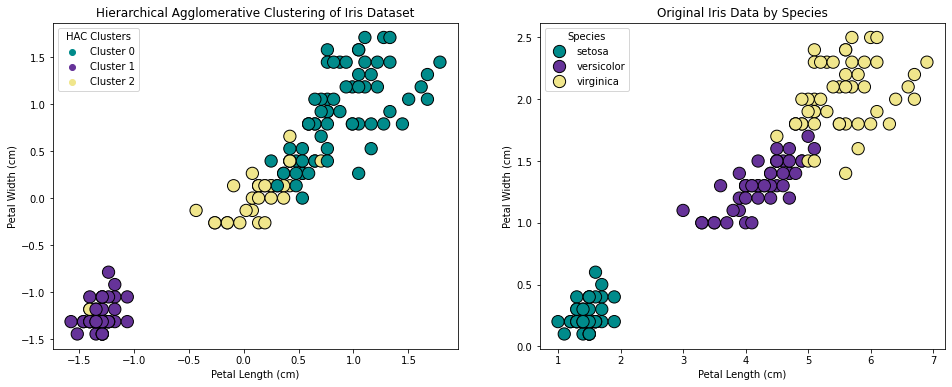

In [13]:
# Custom color mapping for clusters based on HAC labels
cluster_colors = {0: 'darkcyan', 1: 'rebeccapurple', 2: 'khaki'}
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

# Visualization of Clusters
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# HAC Cluster Visualization
hac_cluster_colors_list = [cluster_colors[label] for label in iris_data['cluster_HAC']]
ax[0].scatter(scaled_iris_features['petal_length'], scaled_iris_features['petal_width'], c=hac_cluster_colors_list, edgecolor='k', s=150)
ax[0].set_title('Hierarchical Agglomerative Clustering of Iris Dataset')
ax[0].set_xlabel('Petal Length (cm)')
ax[0].set_ylabel('Petal Width (cm)')

# Adding custom legend for HAC clusters
for cluster_num, color in cluster_colors.items():
    ax[0].scatter([], [], color=color, label=f'Cluster {cluster_num}')
ax[0].legend(title='HAC Clusters')

# Original Data Visualization by Species
species_palette = {'setosa': 'darkcyan', 'versicolor': 'rebeccapurple', 'virginica': 'khaki'}
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=iris_data, ax=ax[1], palette=species_palette, edgecolor='k', s=150)
ax[1].set_title('Original Iris Data by Species')
ax[1].set_xlabel('Petal Length (cm)')
ax[1].set_ylabel('Petal Width (cm)')
ax[1].legend(title='Species')

plt.show()

#### Side-by-Side Scatter Plot

The side-by-side scatter plots show the clustering results of HAC next to the original species classification:

- **HAC Clusters**: The left plot displays clusters obtained from HAC, where we can observe that 'Setosa' (dark cyan points) is clearly separable, while there is some overlap between 'Versicolor' (rebeccapurple points) and 'Virginica' (khaki points).
- **Original Data by Species**: The right plot shows the actual species distribution, which we expect to align with the clustering results. The clear separation of 'Setosa' is consistent with the HAC results, but as noted earlier, 'Versicolor' and 'Virginica' have overlapping regions, reflecting the difficulty in distinguishing between these two species.

In summary, the dendrograms provide valuable insights into the data's hierarchical structure and suggest the number of clusters. The comparative analysis between HAC and actual species reveals that 'Setosa' is easily distinguishable, but 'Versicolor' and 'Virginica' are more challenging to separate due to their similarity. The side-by-side scatter plots offer a visual confirmation of the clusters formed by HAC against the known species labels, reinforcing the conclusions drawn from the heatmap.

## 8. Evaluation and Comparison of Clustering Results

#### Objective
Evaluate the quality of the clusters formed by K-means and hierarchical clustering algorithms on the Iris dataset and compare these results to gain insights.

In [15]:
# Silhouette Coefficient calculation
silhouette_kmeans = silhouette_score(scaled_iris_features, iris_data['cluster_KMeans'])
silhouette_hac = silhouette_score(scaled_iris_features, iris_data['cluster_HAC'])

print(f"Silhouette Coefficient for K-means: {silhouette_kmeans:.2f}")
print(f"Silhouette Coefficient for HAC: {silhouette_hac:.2f}")

Silhouette Coefficient for K-means: 0.46
Silhouette Coefficient for HAC: 0.45


- **Silhouette Scores**: The Silhouette Coefficient scores provide a measure of how similar an object is to its own cluster compared to other clusters. The scores for both K-means and HAC have been calculated, and a higher score indicates a model with better-defined clusters.

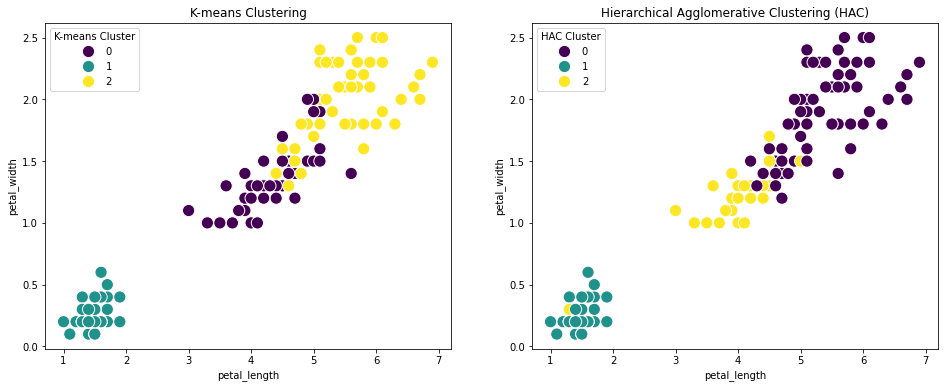

In [20]:
# Side-by-side scatter plot for visual comparison
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# K-means Clusters
sns.scatterplot(x='petal_length', y='petal_width', hue='cluster_KMeans', data=iris_data, palette='viridis', ax=ax[0], s=150)
ax[0].set_title('K-means Clustering')
ax[0].legend(title='K-means Cluster')

# HAC Clusters
sns.scatterplot(x='petal_length', y='petal_width', hue='cluster_HAC', data=iris_data, palette='viridis', ax=ax[1], s=150)
ax[1].set_title('Hierarchical Agglomerative Clustering (HAC)')
ax[1].legend(title='HAC Cluster')

plt.show()

### Results Interpretations :
The side-by-side scatter plots and the Silhouette Coefficients provide a clear basis for evaluating and comparing the K-means and Hierarchical Agglomerative Clustering (HAC) applied to the Iris dataset.

#### K-means Clustering Results

The scatter plot for K-means clustering shows three distinct groups, with the 'Setosa' species (cluster 0) clearly separated from the other two species, which are 'Versicolor' (cluster 1) and 'Virginica' (cluster 2). The 'Versicolor' and 'Virginica' clusters have some overlap, which is expected due to the inherent similarities between these species. The Silhouette Coefficient for K-means is 0.46, which indicates that on average, data points are closer to the other points in their cluster than to points in other clusters, but there's room for improvement, especially in distinguishing between 'Versicolor' and 'Virginica'.

#### Hierarchical Agglomerative Clustering (HAC) Results

The HAC scatter plot also shows three groups. However, the distribution of clusters is slightly different compared to K-means. There's a more pronounced mixing between 'Versicolor' and 'Virginica', suggesting that the 'ward' linkage criterion used might be less effective in separating these two species than the K-means algorithm. The Silhouette Coefficient of 0.45 is very close to that of K-means, implying that the quality of the clusters in terms of separation and cohesion is similar between the two methods.

#### Conclusion

Both K-means and HAC have produced relatively good clusters with a small difference in their Silhouette Coefficients. Neither method perfectly separates all three species, which aligns with the understanding that 'Versicolor' and 'Virginica' are more difficult to distinguish from each other. The K-means algorithm has a slightly higher Silhouette Coefficient, suggesting that it may have done a marginally better job at clustering this particular dataset.

#### Additional Information

While the Silhouette Coefficient gives an overall indication of the clustering quality, it does not tell the whole story. It's essential to consider other evaluation metrics and to interpret the results within the context of the dataset:

- **Cohesion and Separation**: Other metrics such as the Davies-Bouldin index or within-cluster sum of squares could provide further insights into the cohesion and separation of the clusters.

- **Nature of Clusters**: If the clusters have a non-spherical shape or vary significantly in size, algorithms like DBSCAN or Gaussian Mixture Models might yield better results as they can capture more complex cluster shapes.

- **Real-world Application**: Understanding the domain context is crucial. In some cases, it might be more important to have highly cohesive clusters than well-separated ones, or vice versa.

In conclusion, both clustering methods have provided useful insights into the Iris dataset's structure, with K-means showing a slight edge in cluster quality as per the Silhouette Coefficient. However, given the similarities in scores and the visualization, it can be said that both methods are reasonably effective for this dataset. It's important to consider both the quantitative metrics and the visualizations when evaluating clustering results.